# Synthetic Experiments using Realistic Schedules

Not adversarial schedules. Following the FKC paper, we sample 10k samples with 1000 sampling steps.

Device: cuda


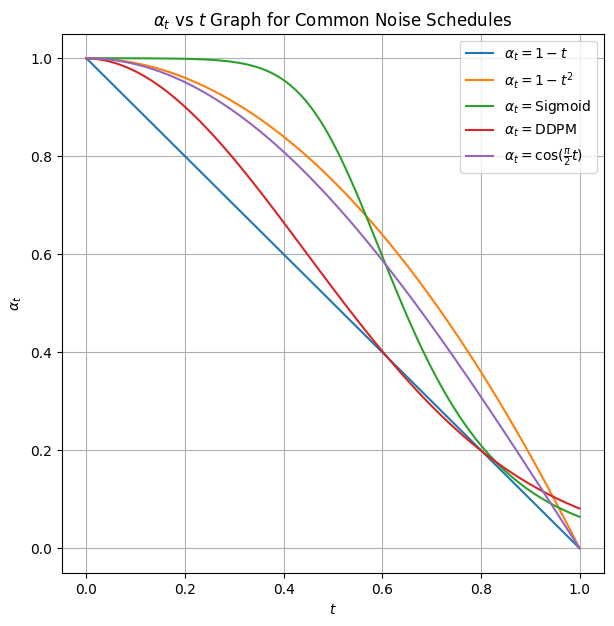

There are 24 unique combinations that have path collapse:


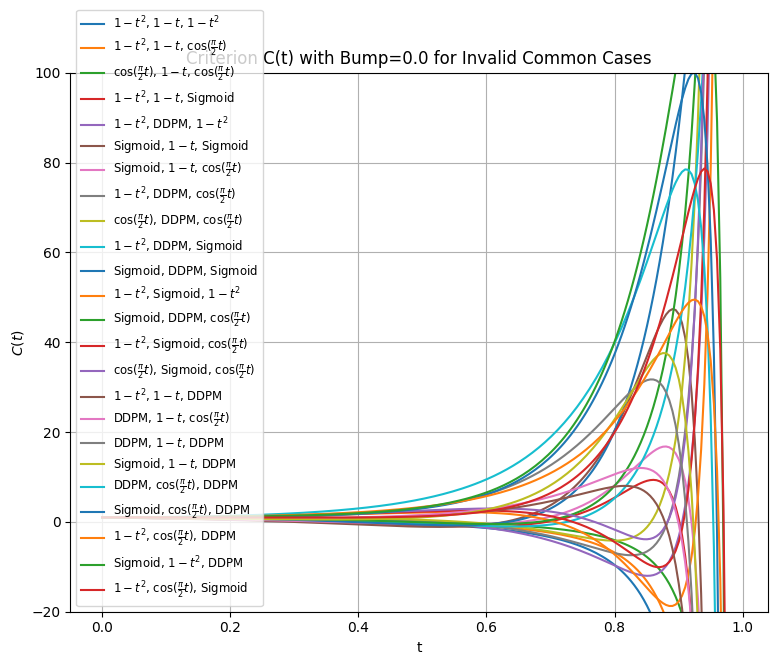

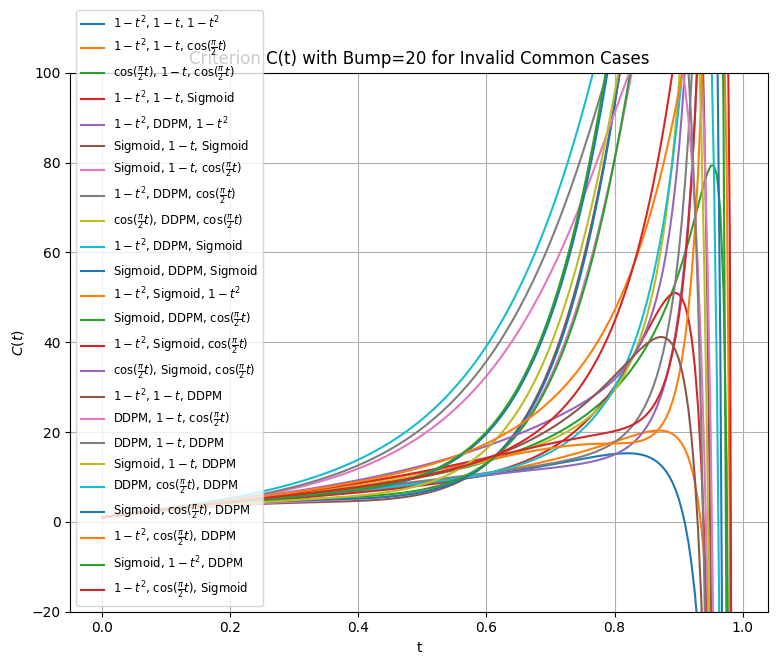

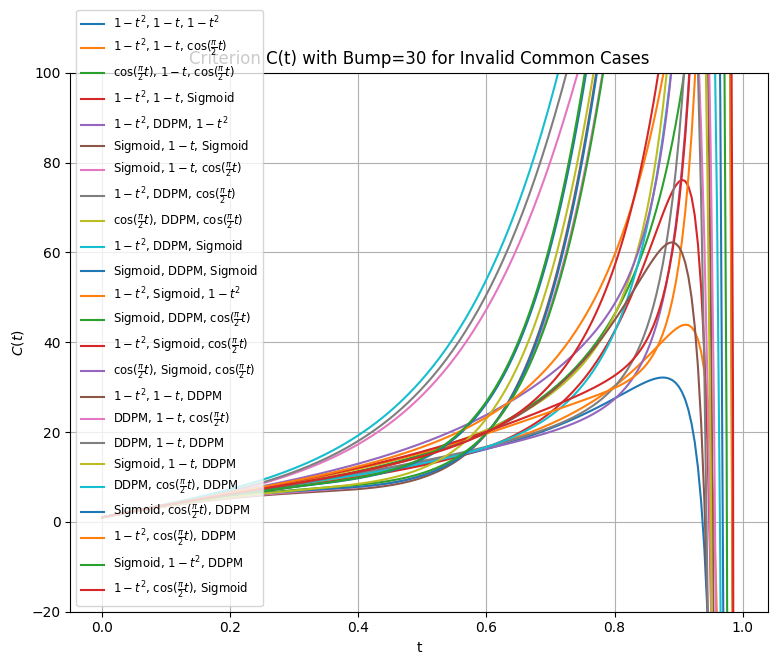

In [ ]:
%reload_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized
from hcg.interpolant import Interpolant as Interpolant
from hcg.interpolant import FlowMatcher as FlowMatcher
from hcg.interpolant import plot_path_trajectories as plot_path_trajectories
import json
from IPython.display import clear_output
import itertools
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("Device:", device)

top_experiment_id = "[251115] Rebuttal Experiments"  # Use a fixed ID for reproducibility
if not os.path.exists(top_experiment_id):
    os.makedirs(top_experiment_id)

model_path = "PretrainedToyModels"

experiment_id = f"{top_experiment_id}/common_schedules"
if os.path.exists(experiment_id) is False:
    os.makedirs(experiment_id)

def load_interpolants_from_json_alpha_only(path):
    with open(path, "r") as f:
        interpolants_raw = json.load(f)

    interpolants = {}
    for name, funcs in interpolants_raw.items():
        alpha_t = eval(funcs["alpha_t"], {"torch": torch})
        interpolants[name] = alpha_t
    return interpolants

# Load
interpolants = load_interpolants_from_json_alpha_only("interpolant_schedules.json")
names = list(interpolants.keys())

t = torch.linspace(0.0, 1.0, 100)

name_eq = {
    "ddpm_linear": r"$\alpha_t = \text{DDPM}$",
    "1-t**2": r"$\alpha_t = 1-t^2$",
    "sigmoid": r"$\alpha_t = \text{Sigmoid}$",
    "default_linear": r"$\alpha_t = 1-t$",
    "cos_t": r"$\alpha_t=\cos(\frac{\pi}{2}t)$"
}

plt.figure(figsize=(7, 7)) 
for name in interpolants.keys():
    plt.plot(t.numpy(), interpolants[name](t).numpy(), label=name_eq[name])
plt.xlabel(r'$t$')
plt.ylabel(r'$\alpha_t$')
plt.title(r'$\alpha_t$ vs $t$ Graph for Common Noise Schedules')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "alpha_t_plot_common_schedules.png"))
plt.show()
plt.close()

def check_condition(alpha_funcs, n_grid=200, Bump = 0.0, Anneal_weight=1.0):
    """Check sign conditions for [a1, a2, a3]. a1 a3 / a2 and anneal weight applies to (a1 / a2)^w a3"""
    ts = torch.linspace(0.0, 0.99, n_grid)

    if n_grid > 1:
        dt = ts[1] - ts[0]
    else:
        dt = torch.tensor(0.0) 

    alphas = [f(ts) for f in alpha_funcs]
    Bumps = torch.tensor([Bump * t * (1-t) for t in ts])
    if len(alpha_funcs) == 3:
        C = (Anneal_weight + Bumps) / (alphas[0]**2 + 1e-12) - Anneal_weight / (alphas[1]**2 + 1e-12) + 1 / (alphas[2]**2 + 1e-12)
    else:
        raise ValueError("Only supports 3 schedules")

    total_negative_length = 0.0
    if n_grid > 1:
        negative_intervals = C[:-1] < 0
        total_negative_length_tensor = torch.sum(negative_intervals.float()) * dt
        total_negative_length = total_negative_length_tensor.item()

    return (C.min() < 0), ts, C, total_negative_length

name_eq_plot = {
    "ddpm_linear": r"$\text{DDPM}$",
    "1-t**2": r"$1-t^2$",
    "sigmoid": r"$\text{Sigmoid}$",
    "default_linear": r"$1-t$",
    "cos_t": r"$\cos(\frac{\pi}{2}t)$"
}


def find_valid_combinations(interpolants, Anneal_weight=1.0, Bump=0.0):
    collapse_combinations = []

    for a1, a2, a3 in itertools.product(interpolants, repeat=3):
        valid, t, C, total_negative_length = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], Anneal_weight=Anneal_weight, Bump=Bump)
        if valid:
            collapse_combinations.append([a1, a2, a3, total_negative_length])
    collapse_combinations.sort(key=lambda x: x[3], reverse=True)
    unique_combinations = []
    seen = set()
    for combo in collapse_combinations:
        identifier = combo[3]
        if identifier not in seen:
            unique_combinations.append(combo)
            seen.add(identifier)
    collapse_combinations = unique_combinations # Remove duplicates if total_negative_length is the same
    return collapse_combinations

collapse_combinations = find_valid_combinations(interpolants, Anneal_weight=1.0, Bump=0.0)
print(f"There are {len(collapse_combinations)} unique combinations that have path collapse:")

with open(os.path.join(experiment_id, "collapse_combinations.json"), "w") as f:
    json.dump(collapse_combinations, f, indent=4)

for Bump in [0.0, 20, 30]:
    plt.figure(figsize=(9,7))
    plt.title(f'Criterion C(t) with Bump={Bump} for Invalid Common Cases')
    for names in collapse_combinations:
        a1, a2, a3, invalid_interval = names
        valid, t, C, invalid_interval = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], Anneal_weight=1.0, Bump=Bump)
        plt.ylim((-20,100))
        plt.grid(True)
        plt.plot(t.numpy(), C.numpy(), label=f'{name_eq_plot[a1]}, {name_eq_plot[a2]}, {name_eq_plot[a3]}')
        plt.legend(loc='lower left', fontsize='small')
    plt.xlabel('t')
    plt.ylabel(r"$C(t)$")
    plt.savefig(os.path.join(experiment_id, f"Criterion_plot_a1a2a3_bump={Bump}.png"))
    plt.show()
    plt.close()

for names in collapse_combinations:
    bs = 10000; n_steps=1000
    seeds = [0,1,2,3,4]
    ESS_THRESHOLD = 0.7
    ANNEAL_WEIGHT = 1.0
    BUMP_VALUE = 30.0
    RUN_METRIC_EVAL = True
    results = []

    subexperiment_id = f"{names}"
    experiment_id = f"{top_experiment_id}/[{names[3]:.4f}]{subexperiment_id}_Realistic_Synthetic_Schedule_for_MPC"
    if not os.path.exists(experiment_id):
        os.makedirs(experiment_id)

    u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
    s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
    u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
    s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
    u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
    s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

    def v1_fn(x, t, A): return u_model1(x, t, A)
    def s1_fn(x, t, A): return s_model1(x, t, A)
    def v2_fn(x, t): return u_model3(x, t)
    def s2_fn(x, t): return s_model3(x, t)
    def v3_fn(z, t, B): return u_model2(z, t, B)
    def s3_fn(z, t, B): return s_model2(z, t, B)
    def sigma_fn(t): return 0.5 * torch.ones_like(t)

    v_fn_list=[
            lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
            lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
            lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
        ]
    s_fn_list=[
            lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
            lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
            lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
        ]
    proj_list=[
            lambda z: z[:, :1],    # project to X 
            lambda z: z[:, :1],    # project to X
            lambda z: z            # identity for Z
        ]
    emb_list=[
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda z: z  # identity
        ]
    print(f"{names} models loaded.")


    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        print(f"Seed set to {seed}")

        for Method_name in ["FKC", "ACE"]:
            print(f"Method: {Method_name}")
            if Method_name == "FKC":
                    print("Simulating FKC (Constant Gammas)")
                    gamma_list = [
                        lambda t : torch.tensor(1) * ANNEAL_WEIGHT,
                        lambda t : torch.tensor(-1) * ANNEAL_WEIGHT,
                        lambda t : torch.tensor(1)
                    ]
                    d_gamma_list = [
                        lambda t: torch.zeros_like(t),
                        lambda t: torch.zeros_like(t),
                        lambda t: torch.zeros_like(t)
                    ]
            elif Method_name == "ACE":
                print("Simulating ACE (Adaptive Gammas)")
                gamma_list = [
                    lambda t : torch.tensor(1) * ANNEAL_WEIGHT + (BUMP_VALUE * t * (1 - t)),
                    lambda t : torch.tensor(-1) * ANNEAL_WEIGHT,
                    lambda t : torch.tensor(1)
                ]
                d_gamma_list = [
                    lambda t: torch.zeros_like(t) + (BUMP_VALUE * (1 - 2*t)),
                    lambda t: torch.zeros_like(t),
                    lambda t: torch.zeros_like(t)
                ]
            if seed == 0:
                Criterion = lambda t: sum([ gamma_list[i](t) / (interpolants[names[i]](t))**2 for i in range(len(names)-1) ])
                t = torch.linspace(0.0, 0.99, 100)
                plt.plot(t.numpy(), Criterion(t).numpy())
                plt.xlabel('t')
                plt.ylabel('Criterion C(t)')
                plt.title('Criterion C(t) vs t')
                plt.grid(True)
                plt.ylim(-20,100)
                plt.savefig(os.path.join(experiment_id, f"Criterion_plot_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}_Method={Method_name}.png"))
                plt.show()
                plt.close()

            # print when Criterion = 0
            for i in range(len(t)-1):
                if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
                    print("Criterion = 0 at t =", t[i].item())
                    break
            for i in range(len(t)-1):
                if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
                    print("Criterion = 0 at t =", t[i].item())
                    break
            for A, B in [(1,1), (1,0), (0,1), (0,0)]:
                print(f"Conditioning on A={A}, B={B}")

                x0 = torch.randn(bs, 2).to("cuda")
                samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
                    x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
                    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
                    t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=ESS_THRESHOLD, print_resample_history=True,
                    gamma_list=gamma_list,
                    d_gamma_list=d_gamma_list,
                    resample=True
                )
                samples = samples.cpu().numpy()
                if seed == 0:
                    plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_{Method_name}_seed{seed}_AB={A}{B}_Bump={BUMP_VALUE}")
                    plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_{Method_name}_seed{seed}_AB={A}{B}_Bump={BUMP_VALUE}", deg=-50)
                    plt.close(); clear_output()

                if RUN_METRIC_EVAL:
                    print(f"Evaluating {Method_name} for AB={A}{B}")
                    samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
                    w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
                        torch.tensor(samples_gt), torch.tensor(samples)
                    )
                    results.append([seed, Method_name, w1, w2, mmd_rbf, total_var, A, B])

                    df = pd.DataFrame(results, columns=["seed", "method", "W1", "W2", "MMD_RBF", "Total Var.", "A", "B"])
                    df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}_n_steps{n_steps}_ESS{ESS_THRESHOLD}_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}.csv", index=False)